In [1]:

# Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import write, read
from IPython.display import Audio
import IPython

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.signal import sawtooth, square
from IPython.display import Audio, HTML
    
%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

import soundfile as sf
from urllib.request import urlopen
import io

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")




# Amplitude Modulation vs Ringmodulation




Both amplitude modulation and ringmodulation are based on the
multiplication of two signals - a carrier $c$ and a modulator $x$.
The basic formula is the same for both:

$$y(t) = x(t) \cdot c(t)$$


However, the carrier signals are different:

**For ringmodulation both the carrier and the modulator are symmetric (bipolar)**:

$$y(t) = \sin\left[2 \pi f_c t\right] \cdot \left(\sin\left[2 \pi f_m t\right]\right)$$

**For amplitude modulation, the carrier ist asymmetric (unipolar)**:

$$y(t) = \left( 1+ m  \sin \left[ 2 \pi f_c t \right] \right) 
\cdot \left(\sin\left[2 \pi f_m t\right]\right)$$

This differnce has an influence on the resulting spectrum and on the sound,
as the following examples show.


In [2]:


# define functions for AM and ringmod

def am(f1, f2, t):
    
    x = np.sin(2*np.pi*f1*t)
    m = 1+np.sin(2*np.pi*f2*t)

    y = x*m    
    return(y,m,x)



def ringmod(f1, f2, t):
    
    x = np.sin(2*np.pi*f1*t)
    m = np.sin(2*np.pi*f2*t)

    y = x*m    
    return(y,m,x)


---

# AM Spectrum


In the discrete time case, the spectrum for amplitude modulation can 
be calculated as follows:

$$Y[k] = DFT(y[n])$$

The modulation index is set to $m=1$:
 
$$\begin{align}
Y[k] = &  \sum_{n=0}^{N-1} y[n] \cdot e^{-j 2 \pi k \frac{n}{N}}\\
=&   \sum_{n=0}^{N-1} \sin\left(2 \pi f_c \frac{n}{f_m}\right) \cdot \left( 1+ \sin\left[2 \pi f_m \frac{n}{f_m}\right]\right)   \cdot e^{-j 2 \pi k \frac{n}{N}} \\
&\\
& \textsf{\hspace{80pt} Use: } \sin(a) \cdot \sin(b) = 0.5 (\cos(a-b) - \cos(a+b) \\
&\\
=&\sum_{n=0}^{N-1} \left( \sin\left(2 \pi f_c \frac{n}{f_m}\right) + 0.5 \left( \cos\left(2 \pi (f_c - f_m)\frac{n}{f_m}\right)  - \cos\left(2 \pi (f_1 + f_m)\frac{n}{f_m}\right)  \right) \right)  \cdot e^{-j 2 \pi k \frac{n}{N}} \\
&\\
& \textsf{\hspace{40pt} Sines/cosines appear as $\delta$-peaks at the relevant frequency bin.} \\
&\\
= & \boxed{\delta[f_c] + 0.5 \delta[f_c - f_m] + 0.5 \ \delta[f_c + f_m]}
\end{align}$$

AM creates a spectrum with a **peak at the carrier frequency and 
two additional peaks - one below and one above the carrier**. Their position is defined by the difference between carrier and modulator.
For a modulation index of $m=1$, the sidebands have half the carrier's amplitude.

The following example shows an AM signal with a carrier frequency $f_c = 10$Hz
and a modulator frequency of $f_m=200$Hz.

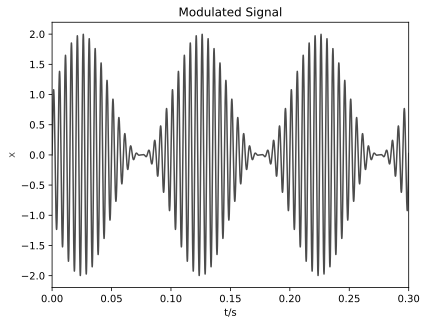

In [7]:
# visualization in the time domain

# basic parameters
fs = 16000
L  = 16000

t  = np.linspace(0,1,L)
f  = np.linspace(-0.5,0.5,L)


f_car = 10
f_mod = 200
[x, x_car, x_sig] = am(f_mod, f_car, t)
 

fig1, ax1 = plt.subplots()
 
plt.title("Modulated Signal")

ax1.set_xlabel('t/s')
ax1.set_ylabel('x' ,color = [ 0.3, 0.3, 0.3])
ax1.set_xlim(0, 0.3) 

 
line, = ax1.plot(t,x,color=[0.3,0.3,0.3]);
 


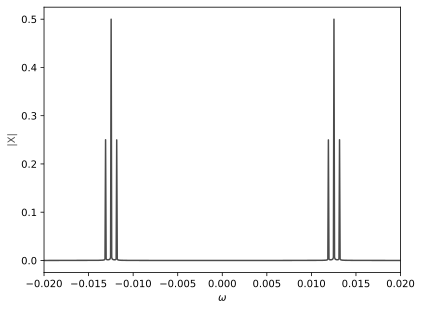

In [8]:
# visualization in the frequency domain

 
[x, x_car, x_sig] = am(f_mod, f_car, t)

# fft stuff   
X = np.fft.fftshift(np.fft.fft(x))
X = X/(L)

X_car = np.fft.fftshift(np.fft.fft(x_car))
X_car = X_car/(L)

X_sig = np.fft.fftshift(np.fft.fft(x_sig))
X_sig = X_sig/(L)


fig1, ax1 = plt.subplots()
 
ax1.set_xlabel('$\omega$')
ax1.set_ylabel('|X|' ,color = [ 0.3, 0.3, 0.3])
ax1.set_xlim(-0.02, 0.02) 

# for static HTML output:
line, = ax1.plot(f,abs(X),color=[0.3,0.3,0.3]);
 


-----

# Ringmodulator Spectrum

The spectrum of a ringmodulator is calculated in the continous time domain for this example.

$$\begin{align}
\mathcal{F} [ y(t)]  = & \int\limits_{-\inf}^{\inf} y(t) e^{-j 2 \pi f t} \mathrm{d}t\\
=&  \int\limits_{-\inf}^{\inf} \left( \sin(2 \pi f_c t) \cdot \sin(2 \pi f_m t) \right) e^{-j 2 \pi f t} \mathrm{d}t\\
&\\
& \textsf{Use Euler to get complex representation:}\\
&\\
=& \frac{1}{2 j} \int\limits_{-\inf}^{\inf} \left( (-e^{-j 2 \pi f_c t} +e^{j 2 \pi f_c t})  (-e^{-j 2 \pi f_m t} +e^{j 2 \pi f_m t}) \right) \ e^{-j 2 \pi f t} \mathrm{d}t\\
=& \frac{1}{2 j}  \int\limits_{-\inf}^{\inf} \left(  e^{j 2 \pi (f_c+f_m) t} - e^{j 2 \pi (f_c-f_m) t}  - e^{j 2 \pi (-f_c+f_m) t} + e^{j 2 \pi (-f_c-f_m) t} \right) e^{-j 2 \pi f t} \mathrm{d}t\\
&\\
& \textsf{Each exponential represents a peak in the spectrum (including positive and negative):}\\
&\\
=& \frac{1}{2 j} \left[ \delta(f_c+f_m)   -\delta(f_c-f_m) - \delta(-f_c+f_m)  + \delta(-f_c-f_m)  \right]
\end{align}$$    
    
Ringmodulation creates **a spectrum with two peaks - one below and one above the carrier frequency**. 
Their position is defined by the difference between carrier and modulator. **The carrier is supressed, since it is a bipolar signal.**


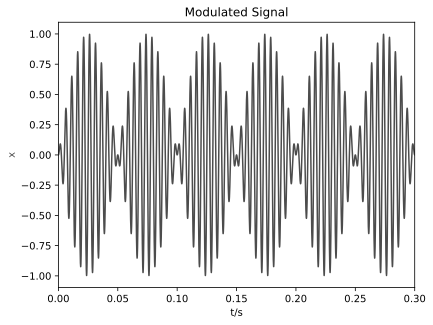

In [5]:
# visualization in the time domain

# basic parameters

f_car = 10
f_mod = 200

t  = np.linspace(0,1,L)
f  = np.linspace(-0.5,0.5,L)
 
[x, x_car, x_sig] = ringmod(f_mod, f_car, t)
 

fig1, ax1 = plt.subplots()
 
plt.title("Modulated Signal")

ax1.set_xlabel('t/s')
ax1.set_ylabel('y' ,color = [ 0.3, 0.3, 0.3])
ax1.set_xlim(0, 0.3) 
 

line, = ax1.plot(t,x,color=[0.3,0.3,0.3]);

 


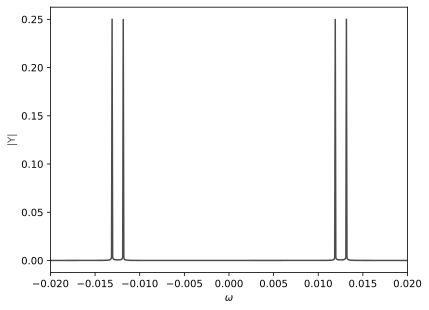

In [9]:
# visualization in the frequency domain
 
[x, x_car, x_sig] = ringmod(f_mod, f_car, t)

# fft stuff   
X = np.fft.fftshift(np.fft.fft(x))
X = X/(L)

X_car = np.fft.fftshift(np.fft.fft(x_car))
X_car = X_car/(L)

X_sig = np.fft.fftshift(np.fft.fft(x_sig))
X_sig = X_sig/(L)


fig1, ax1 = plt.subplots()
 
ax1.set_xlabel('$\omega$')
ax1.set_ylabel('|Y|' ,color = [ 0.3, 0.3, 0.3])
ax1.set_xlim(-0.02, 0.02) 

# for static HTML output:
line, = ax1.plot(f,abs(X),color=[0.3,0.3,0.3]);
 
